# tinytorchcompile demo

`torch.compile` in a nutshell, showing its main idea: **operator fusion**. This notebook shows-
1. Operator fusion of `(w * x + b).relu().sum()` through tinytorchcompile (fused vs unfused, a 3.8x speedup) and `torch.compile`: time compariosn, kernel counts, fused kernel diagrams, and the generated code from both.
2. ResNet layer via `torch.compile`: time comparison, fused kernel diagram, and the generated highly optimized C++ code. A detailed explanation of operator fusion is in the README of [tinytorchcompile](https://github.com/purohit10saurabh/tinytorchcompile).

## Helper functions

Benchmarking, correctness checks, code printing, kernel counting, and mermaid diagram rendering. It is not a part of the compiler, so **scroll down for the main content below** .

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import tinytorchcompile as ttc

rng = np.random.default_rng(0)


def bench(fn, *args, n=30, warmup=3):
    for _ in range(warmup):
        fn(*args)
    t = time.perf_counter()
    for _ in range(n):
        fn(*args)
    return (time.perf_counter() - t) / n * 1e3


def as_numpy(out):
    return out.detach().numpy() if hasattr(out, "detach") else out


def row(label, ref, fn, *args, kernels=None):
    correct = np.allclose(as_numpy(fn(*args)), ref)
    counts = "" if kernels is None else "kernels=%d  " % kernels
    print("%-22s %scorrect=%s  %6.2f ms" % (label, counts, correct, bench(fn, *args)))


def print_code(title, code, limit=100):
    lines = code.splitlines()
    print(chr(10) + ('--- %s ---' % title) + chr(10) + chr(10).join(lines[:limit]))
    if len(lines) > limit:
        print('... [truncated, %d more lines]' % (len(lines) - limit))


def eager_kernels(fn, *args):
    from torch.utils._python_dispatch import TorchDispatchMode

    class _OpCount(TorchDispatchMode):
        def __init__(self):
            self.n = 0

        def __torch_dispatch__(self, func, types, args=(), kwargs=None):
            self.n += 1
            return func(*args, **(kwargs or {}))

    counter = _OpCount()
    with counter:
        fn(*args)
    return counter.n


def torch_kernels(code):
    import re
    return len(re.findall(r"cpp_fused[a-z0-9_]*_\d+\s*=\s*async_compile", code))


def show_mermaid(src):
    import base64, urllib.request, IPython.display as ipy
    url = "https://mermaid.ink/img/" + base64.urlsafe_b64encode(src.encode()).decode()
    ipy.display(ipy.Image(urllib.request.urlopen(urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"}), timeout=15).read()))


def micro_mermaid(fn, inputs, fuse):
    order, bufs = ttc.lower(fn(*[ttc.input(getattr(a, "shape", ())) for a in inputs]))
    ttc.schedule(order, bufs, fuse=fuse)
    mats, owner = [n for n in order if ttc.materialized(bufs[id(n)])], {}
    for m in mats:
        stack = [m]
        while stack:
            n = stack.pop()
            if bufs[id(n)].is_input or id(n) in owner or (ttc.materialized(bufs[id(n)]) and n is not m):
                continue
            owner[id(n)] = m
            stack += n.inputs
    nid = {id(n): "n%d" % i for i, n in enumerate(order)}
    kind = lambda b: "matmul" if b.is_matmul else "reduce" if b.is_reduction else "pointwise"
    label = lambda n: "const %g" % n.const if n.op == "const" else "%s %s" % (n.op, tuple(n.shape))
    lines = ["flowchart LR"]
    for i, m in enumerate(mats):
        members = [n for n in order if owner.get(id(n)) is m]
        lines.append('  subgraph k%d ["kernel %d \u00b7 %s (%d ops)"]' % (i, i, kind(bufs[id(m)]), len(members)))
        lines += ['    %s["%s"]' % (nid[id(n)], label(n)) for n in members]
        lines.append("  end")
    lines += ['  %s(["in %s"])' % (nid[id(n)], tuple(n.shape)) for n in order if bufs[id(n)].is_input]
    for n in order:
        lines += ["  %s --> %s" % (nid[id(c)], nid[id(n)]) for c in n.inputs]
    return "\n".join(lines)


def torch_mermaid(code):
    import re
    clean = lambda s: " + ".join(s.replace("_native_batch_norm_legit_no_training", "batchnorm").strip("_").split("_"))
    ks = re.findall(r"cpp_fused_([a-z0-9_]+)_(\d+)\s*=\s*async_compile", code)
    nodes = ['  k%s["kernel %s: %s"]' % (i, i, clean(ops)) for ops, i in ks]
    edges = ["  k%s --> k%s" % (ks[j - 1][1], ks[j][1]) for j in range(1, len(ks))]
    return "\n".join(["flowchart LR"] + nodes + edges)

## 1. Operator fusion: `(w * x + b).relu().sum()` fused into one kernel, massive speedup

tinytorchcompile fused kernels=1  correct=True    7.79 ms


tinytorchcompile unfused kernels=4  correct=True   29.87 ms


torch eager            kernels=4  correct=True   11.69 ms
torch.compile          kernels=1  correct=True    1.89 ms

tinytorchcompile fuses 4 ops into 1 kernel:


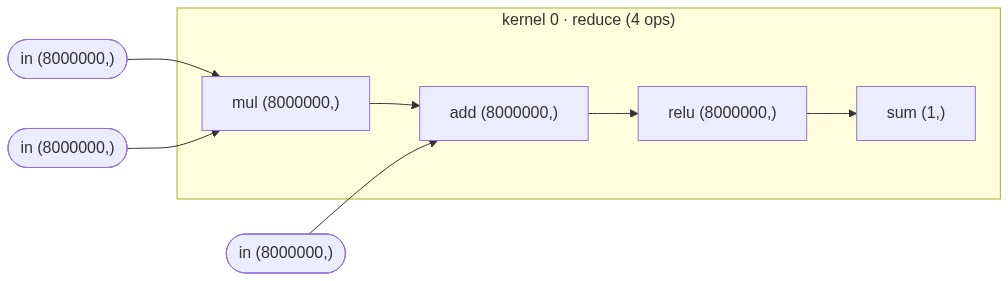

torch.compile fused kernel:


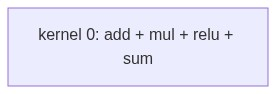

In [2]:
w, x, b = (rng.standard_normal(8_000_000) for _ in range(3))
chain = lambda w, x, b: (w * x + b).relu().sum()
ref = np.maximum(w * x + b, 0.0).sum()
fused = ttc.compile_graph(chain, [w, x, b], fuse=True)
unfused = ttc.compile_graph(chain, [w, x, b], fuse=False)

import torch
from torch._inductor.utils import run_and_get_code

tw, tx, tb = (torch.from_numpy(t) for t in (w, x, b))
torch_chain = lambda w, x, b: torch.relu(w * x + b).sum()
torch._dynamo.reset()
_, code = run_and_get_code(torch.compile(torch_chain), tw, tx, tb)
torch_code = code[0]

row("tinytorchcompile fused", ref, fused, w, x, b, kernels=fused.num_kernels)
row("tinytorchcompile unfused", ref, unfused, w, x, b, kernels=unfused.num_kernels)
row("torch eager", ref, torch_chain, tw, tx, tb, kernels=eager_kernels(torch_chain, tw, tx, tb))
row("torch.compile", ref, torch.compile(torch_chain), tw, tx, tb, kernels=torch_kernels(torch_code))

print("\ntinytorchcompile fuses 4 ops into 1 kernel:")
show_mermaid(micro_mermaid(chain, [w, x, b], fuse=True))
print("torch.compile fused kernel:")
show_mermaid(torch_mermaid(torch_code))

In [3]:
print_code("tinytorchcompile fused C (one reduction kernel, no intermediates)", fused.csrc)
print_code("torch.compile generated kernel (cpp_fused_add_mul_relu_sum)", torch_code)


--- tinytorchcompile fused C (one reduction kernel, no intermediates) ---
#include <math.h>
#include <stdlib.h>

static void kernel_b6(double* in0, double* in1, double* in2, double* out) {
  double acc=0.0; for(long k=0;k<8000000;k++){ acc = acc + (fmax(((in0[k] * in1[k]) + in2[k]), 0.0)); } out[0]=acc;
}

void run(double* in0, double* in1, double* in2, double* out) {
  kernel_b6(in0, in1, in2, out);
}

--- torch.compile generated kernel (cpp_fused_add_mul_relu_sum) ---
# AOT ID: ['0_inference']
from ctypes import c_void_p, c_long, c_int
import torch
import math
import random
import os
import tempfile
from math import inf, nan
from cmath import nanj
from torch._inductor.hooks import run_intermediate_hooks
from torch._inductor.utils import maybe_profile
from torch._inductor.codegen.memory_planning import _align as align
from torch import device, empty_strided
from torch._inductor.async_compile import AsyncCompile
from torch._inductor.select_algorithm import extern_kernels

aten = torch

## 2. ResNet layer via `torch.compile`

tinytorchcompile has no conv; this borrows `torch.compile` to show the same fusion principle on a realistic residual block.

compiled matches eager: True


eager                               15.13 ms


torch.compile          kernels=3   10.94 ms

torch.compile fused kernels:


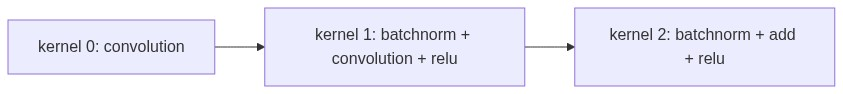

In [4]:
import torch
import torch.nn as nn
from torch._inductor.utils import run_and_get_code


class BasicBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1, self.conv2 = (nn.Conv2d(ch, ch, 3, padding=1, bias=False) for _ in range(2))
        self.bn1, self.bn2 = nn.BatchNorm2d(ch), nn.BatchNorm2d(ch)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        return self.relu(self.bn2(self.conv2(out)) + x)


torch.manual_seed(0)
block = BasicBlock(64).eval()
xb = torch.randn(8, 64, 56, 56)
compiled = torch.compile(block)
with torch.no_grad():
    torch._dynamo.reset()
    _, resnet_code = run_and_get_code(compiled, xb)
    resnet_code = resnet_code[0]
    print("compiled matches eager:", torch.allclose(block(xb), compiled(xb), atol=1e-4))
    print("eager                              %6.2f ms" % bench(block, xb))
    print("torch.compile          kernels=%d  %6.2f ms" % (torch_kernels(resnet_code), bench(compiled, xb)))
print("\ntorch.compile fused kernels:")
show_mermaid(torch_mermaid(resnet_code))

In [5]:
print_code("TorchInductor generated kernel (fused conv/bn/relu)", resnet_code)


--- TorchInductor generated kernel (fused conv/bn/relu) ---
# AOT ID: ['0_inference']
from ctypes import c_void_p, c_long, c_int
import torch
import math
import random
import os
import tempfile
from math import inf, nan
from cmath import nanj
from torch._inductor.hooks import run_intermediate_hooks
from torch._inductor.utils import maybe_profile
from torch._inductor.codegen.memory_planning import _align as align
from torch import device, empty_strided
from torch._inductor.async_compile import AsyncCompile
from torch._inductor.select_algorithm import extern_kernels

aten = torch.ops.aten
inductor_ops = torch.ops.inductor
_quantized = torch.ops._quantized
assert_size_stride = torch._C._dynamo.guards.assert_size_stride
assert_alignment = torch._C._dynamo.guards.assert_alignment
empty_strided_cpu = torch._C._dynamo.guards._empty_strided_cpu
empty_strided_cuda = torch._C._dynamo.guards._empty_strided_cuda
empty_strided_xpu = torch._C._dynamo.guards._empty_strided_xpu
reinterpret_tensor = t